[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\amirb\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'nb__alpha': 1.0, 'tfidf__max_df': 0.8, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}
Validation F1 Score: 0.7440845829366559

✅ Final Model Accuracy on Test Data: 79.93%
------------------------------------------------

🧾 Classification Report (Text Version):
              precision    recall  f1-score   support

    Negative       0.44      0.87      0.58       120
     Neutral       0.95      0.77      0.85      1237
    Positive       0.66      0.87      0.75       352

    accuracy                           0.80      1709
   macro avg       0.68      0.84      0.73      1709
weighted avg       0.85      0.80      0.81      1709



C:\Users\amirb\AppData\Local\Temp\ipykernel_13916\1943288319.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Sentiment'], palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])


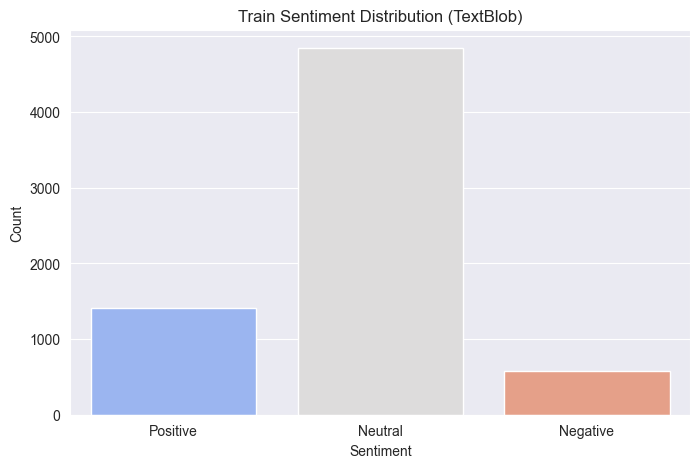

C:\Users\amirb\AppData\Local\Temp\ipykernel_13916\1943288319.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Sentiment'], palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])


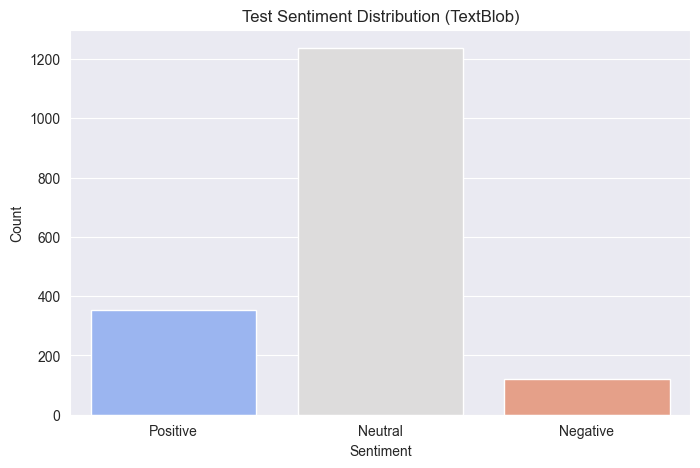

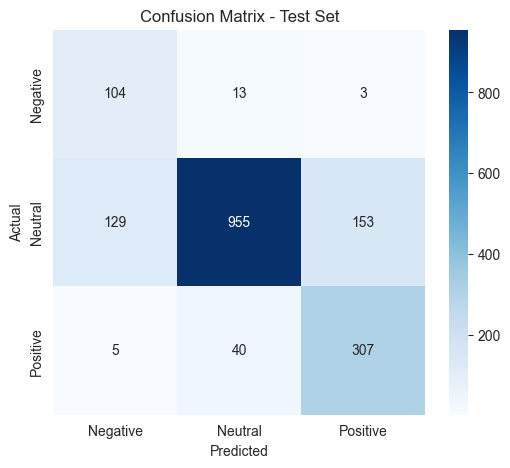

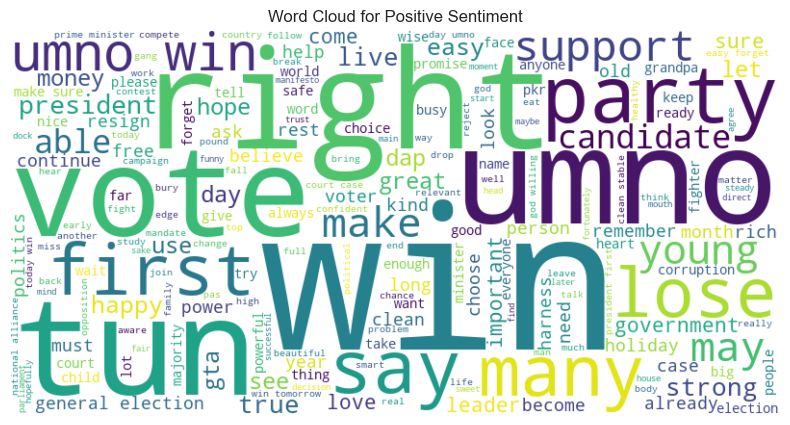

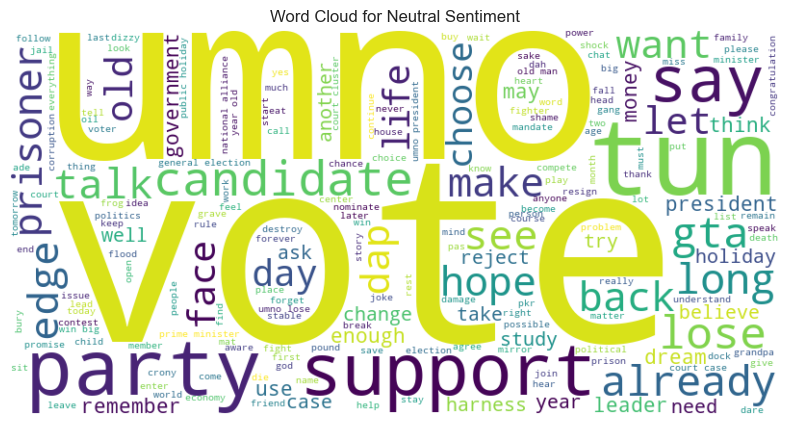

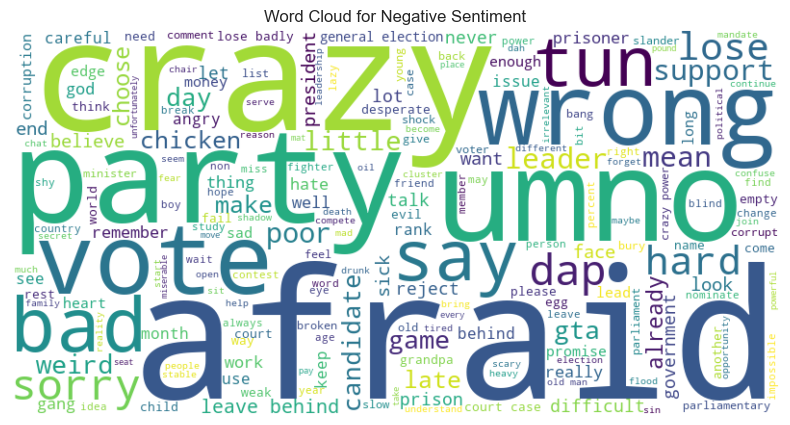

✅ GridSearch-optimized model saved.


In [1]:
# TextBlob Sentiment Analysis with GridSearch, Evaluation, and Visualization

import pandas as pd
import nltk
from textblob import TextBlob
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV, train_test_split
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
import joblib

# Setup
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Utility Functions
def classify_sentiment(text, threshold=0.1):
    if not isinstance(text, str) or not text.strip():
        return "Neutral"
    analysis = TextBlob(text)
    score = analysis.sentiment.polarity
    if abs(score) < threshold or analysis.sentiment.subjectivity < 0.3:
        return "Neutral"
    return "Positive" if score > 0 else "Negative"

def preprocess_text(text):
    if not isinstance(text, str):
        return []
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower().strip()
    words = text.split()
    return [word for word in words if word not in stop_words and len(word) > 2]

def plot_sentiment_distribution(df, title):
    plt.figure(figsize=(8, 5))
    sns.countplot(x=df['Sentiment'], palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])
    plt.title(title)
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.show()

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Load and label datasets
#train_df = pd.read_csv('train_dataset.csv')
#test_df = pd.read_csv('test_dataset.csv')
train_df = pd.read_csv('train_dataset-test.csv')
test_df = pd.read_csv('test_dataset-test.csv')

train_df['Final_Comment'] = train_df['Final_Comment'].astype(str)
test_df['Final_Comment'] = test_df['Final_Comment'].astype(str)

train_df['Sentiment'] = train_df['Final_Comment'].apply(classify_sentiment)
test_df['Sentiment'] = test_df['Final_Comment'].apply(classify_sentiment)

#train_df.to_csv('train_dataset_sentiment_textblob.csv', index=False)
#test_df.to_csv('test_dataset_sentiment_textblob.csv', index=False)
train_df.to_csv('train_dataset_sentiment_textblob-test.csv', index=False)
test_df.to_csv('test_dataset_sentiment_textblob-test.csv', index=False)

sentiment_mapping = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
train_df['Sentiment_Label'] = train_df['Sentiment'].map(sentiment_mapping)
test_df['Sentiment_Label'] = test_df['Sentiment'].map(sentiment_mapping)

train_df.dropna(subset=['Sentiment_Label'], inplace=True)
test_df.dropna(subset=['Sentiment_Label'], inplace=True)

train_df['Sentiment_Label'] = train_df['Sentiment_Label'].astype(int)
test_df['Sentiment_Label'] = test_df['Sentiment_Label'].astype(int)

# Train-test split for GridSearch tuning
X = train_df['Final_Comment']
y = train_df['Sentiment_Label']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('nb', ComplementNB())
])

param_grid = {
    'tfidf__max_df': [0.8, 1.0],
    'tfidf__min_df': [1, 5],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'nb__alpha': [0.1, 0.5, 1.0]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_macro', verbose=2, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Validation F1 Score:", grid.best_score_)

# Final evaluation on test set
X_test = test_df['Final_Comment']
y_test = test_df['Sentiment_Label']
y_pred = grid.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Final Model Accuracy on Test Data: {accuracy * 100:.2f}%")
print("------------------------------------------------")

report = classification_report(y_test, y_pred, target_names=["Negative", "Neutral", "Positive"], output_dict=True)
print("\n🧾 Classification Report (Text Version):")
print(classification_report(y_test, y_pred, target_names=["Negative", "Neutral", "Positive"]))

with open("classification_report_textblob_test.json", "w") as f:
    json.dump(report, f, indent=2)

plot_sentiment_distribution(train_df, "Train Sentiment Distribution (TextBlob)")
plot_sentiment_distribution(test_df, "Test Sentiment Distribution (TextBlob)")
plot_confusion_matrix(y_test, y_pred, "Confusion Matrix - Test Set")

# Word clouds + top words
for sentiment in ["Positive", "Neutral", "Negative"]:
    words = train_df[train_df['Sentiment'] == sentiment]['Final_Comment'].apply(preprocess_text).sum()
    text = ' '.join(words)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Word Cloud for {sentiment} Sentiment")
    plt.show()

# Save final model
#joblib.dump(grid.best_estimator_, 'complementnb_model_textblob.joblib')
joblib.dump(grid.best_estimator_, 'complementnb_model_textblob-test.joblib')
print("✅ GridSearch-optimized model saved.")